In [47]:
import rasterio
import rasterio.mask
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon, box
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd
from reusable import *

#### **Paths and Data**

In [38]:
osm_path = 'cities\singapore\Singapore.osm.pbf'
gtfs_path = 'cities\singapore\mdb-3051-202602171452.zip'
pop_path = 'cities\singapore\sgp_general_population_2020.tif'
city_proj = gpd.read_file("cities/singapore/sg_boundary.zip")

In [4]:
tn = r5.TransportNetwork(osm_path, gtfs=gtfs_path)

#### **Boundaries + grid**

In [36]:
osm = OSM(osm_path)
boundaries = osm.get_boundaries()
#boundaries.sort_values(by="admin_level", ascending=True).head(10)

Using local GeoJSON/Shapefile boundary

In [ ]:
city_proj = gpd.read_file("cities/singapore/sg_boundary.zip")
city_proj = city_proj.to_crs(city_proj.estimate_utm_crs())
city_proj = city_proj.dissolve()

In [31]:
regions = ["North Region", "West Region", 'Central Region', 'North-east Region', 'East Region']
city_boundary = boundaries[boundaries['name'].isin(regions)]
local_crs = city_boundary.estimate_utm_crs()
city_proj = city_boundary.to_crs(local_crs)

<Axes: >

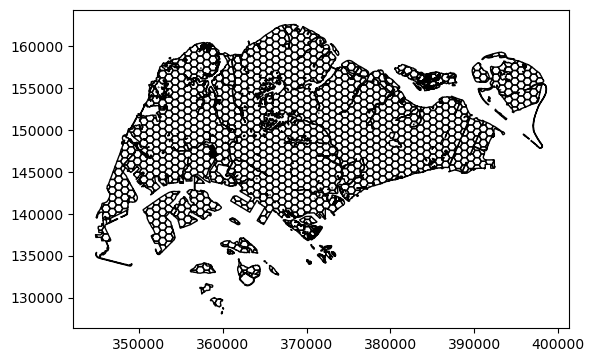

In [35]:
grid = create_hex_grid(city_proj, 500)
grid.plot(edgecolor='black', facecolor='none')

#### **Populating the grid**

Raster total population:  5,826,222
Hex grid total population: 5,818,209
Coverage: 99.9%


c:\Users\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 9 classes. Setting k to 6.
  self.bins = quantile(y, k=k)


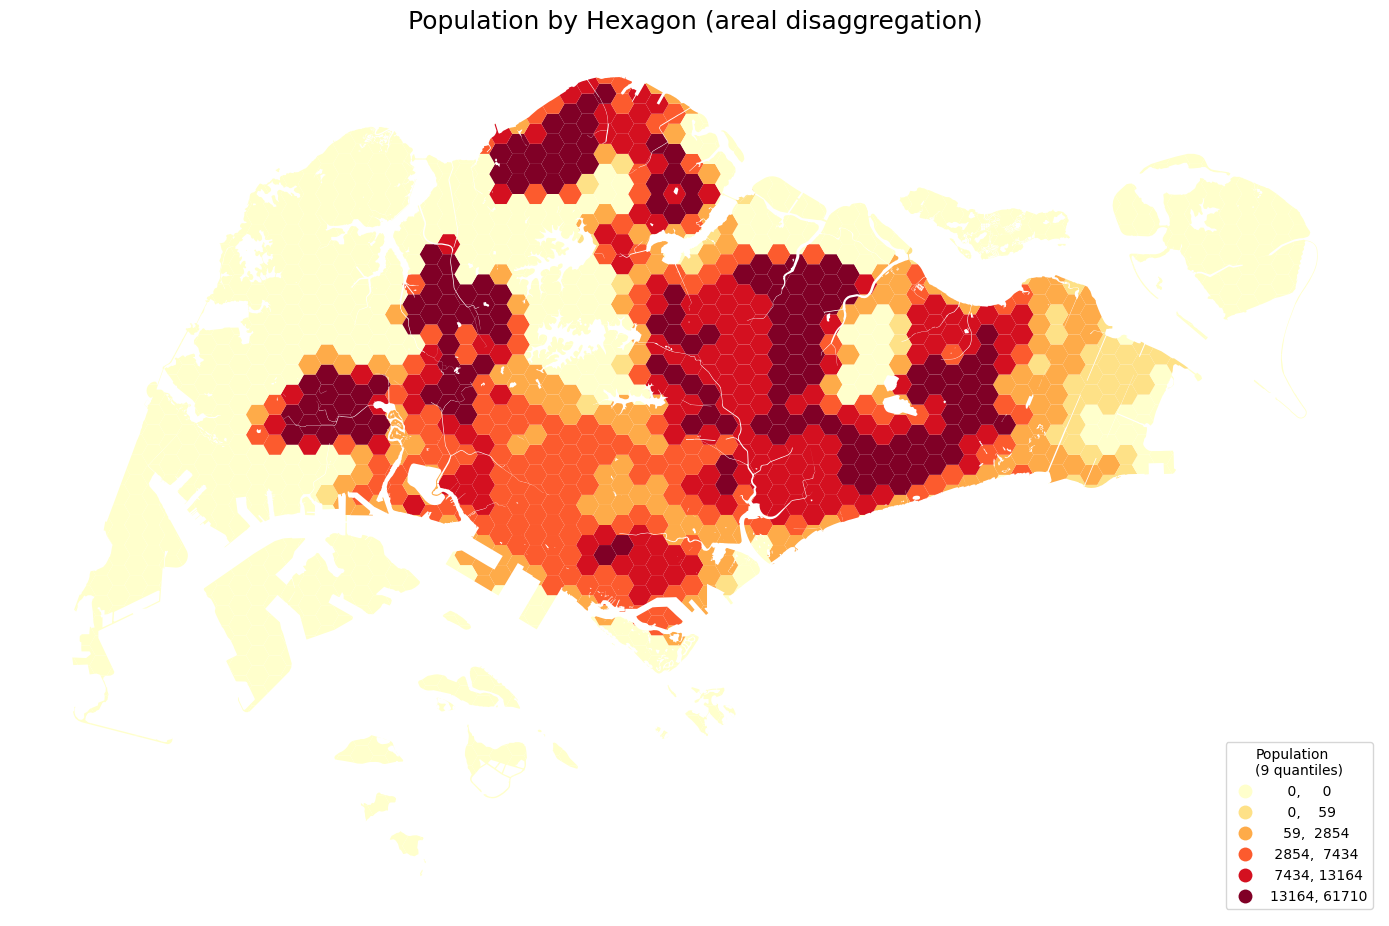

In [43]:
grid_pop = assign_population_to_grid(pop_path, grid, plot=True)

#### **Origins**

In [50]:
origins = create_origins(grid, grid_pop)
origins.head(5)

,geometry,id,population
0,POINT (103.76657 1.18965),0,0.0
1,POINT (103.77125 1.19058),1,0.0
2,POINT (103.76323 1.19257),2,0.0
3,POINT (103.7752 1.19504),3,0.0
4,POINT (103.79998 1.20135),4,0.0


#### **Destinations (POIs)**